C:\Users\tolan\AppData\Local\Temp\ipykernel_43704\1846084988.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{abs(int(t))}" if float(t).is_integer() else f"{abs(t):.1f}" for t in ticks])


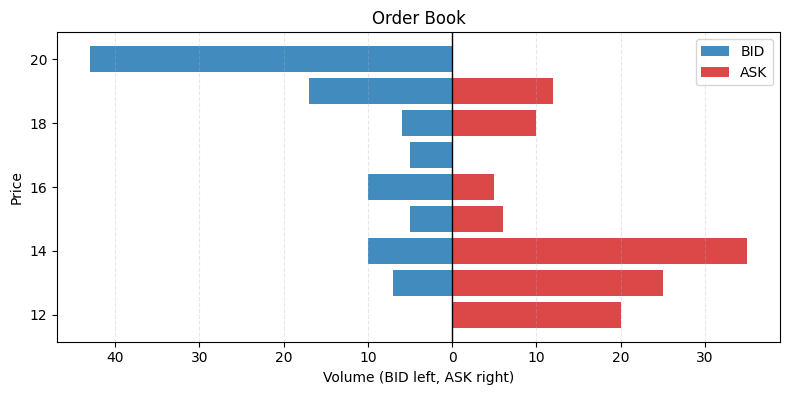

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_order_book(csv_path: str, top_n: int | None = None, sort_desc: bool = True):
    """Plot a simple order book from a CSV with columns: BID, PRICE, ASK.

    BID and ASK are plotted as mirrored horizontal bars at each price level.
    """
    df = pd.read_csv(csv_path)

    required = {"BID", "PRICE", "ASK"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    # Keep numeric rows only and aggregate duplicate price levels.
    book = (
        df[["BID", "PRICE", "ASK"]]
        .apply(pd.to_numeric, errors="coerce")
        .dropna(subset=["PRICE"])
        .fillna(0)
        .groupby("PRICE", as_index=False)[["BID", "ASK"]]
        .sum()
    )

    book = book.sort_values("PRICE", ascending=not sort_desc)
    if top_n is not None:
        book = book.head(top_n)

    fig, ax = plt.subplots(figsize=(8, max(4, len(book) * 0.45)))

    # Mirror bids to the left, asks to the right.
    ax.barh(book["PRICE"], -book["BID"], color="#1f77b4", alpha=0.85, label="BID")
    ax.barh(book["PRICE"],  book["ASK"], color="#d62728", alpha=0.85, label="ASK")

    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("Volume (BID left, ASK right)")
    ax.set_ylabel("Price")
    ax.set_title("Order Book")
    ax.legend()
    ax.grid(axis="x", linestyle="--", alpha=0.3)

    # Use absolute labels on the x-axis for readability.
    ticks = ax.get_xticks()
    ax.set_xticklabels([f"{abs(int(t))}" if float(t).is_integer() else f"{abs(t):.1f}" for t in ticks])

    plt.tight_layout()
    plt.show()


# Example usage:
plot_order_book("EMBER_MUSHROOM.csv")

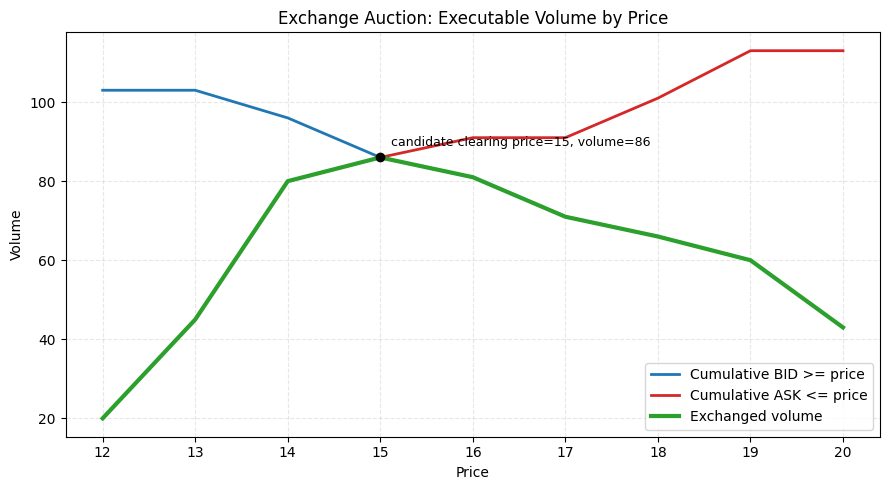

,PRICE,cum_bid_ge_price,cum_ask_le_price,exchanged_volume
0,12,103,20,20
1,13,103,45,45
2,14,96,80,80
3,15,86,86,86
4,16,81,91,81
5,17,71,91,71
6,18,66,101,66
7,19,60,113,60
8,20,43,113,43


In [3]:
def plot_auction_exchanged_volume(csv_path: str):
    """Graph the executable auction volume at each candidate clearing price.

    For each price p:
    - demand(p) = total BID volume at prices >= p
    - supply(p) = total ASK volume at prices <= p
    - exchanged(p) = min(demand(p), supply(p))
    """
    df = pd.read_csv(csv_path)

    required = {"BID", "PRICE", "ASK"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    book = (
        df[["BID", "PRICE", "ASK"]]
        .apply(pd.to_numeric, errors="coerce")
        .dropna(subset=["PRICE"])
        .fillna(0)
        .groupby("PRICE", as_index=False)[["BID", "ASK"]]
        .sum()
        .sort_values("PRICE")
    )

    # Cumulative supply from low to high prices.
    book["cum_ask_le_price"] = book["ASK"].cumsum()

    # Cumulative demand from high to low prices.
    book["cum_bid_ge_price"] = book["BID"][::-1].cumsum()[::-1]

    # Auction matched volume at each candidate clearing price.
    book["exchanged_volume"] = book[["cum_ask_le_price", "cum_bid_ge_price"]].min(axis=1)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(book["PRICE"], book["cum_bid_ge_price"], label="Cumulative BID >= price", color="#1f77b4", linewidth=2)
    ax.plot(book["PRICE"], book["cum_ask_le_price"], label="Cumulative ASK <= price", color="#d62728", linewidth=2)
    ax.plot(book["PRICE"], book["exchanged_volume"], label="Exchanged volume", color="#2ca02c", linewidth=3)

    # Mark one clearing-price candidate with maximal exchanged volume.
    max_exchanged = book["exchanged_volume"].max()
    best = book[book["exchanged_volume"] == max_exchanged].iloc[0]
    ax.scatter(best["PRICE"], best["exchanged_volume"], color="black", zorder=5)
    ax.annotate(
        f"candidate clearing price={best['PRICE']}, volume={best['exchanged_volume']}",
        (best["PRICE"], best["exchanged_volume"]),
        textcoords="offset points",
        xytext=(8, 8),
        fontsize=9,
    )

    ax.set_title("Exchange Auction: Executable Volume by Price")
    ax.set_xlabel("Price")
    ax.set_ylabel("Volume")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    return book[["PRICE", "cum_bid_ge_price", "cum_ask_le_price", "exchanged_volume"]]


# Example usage (switch file name if needed):
plot_auction_exchanged_volume("EMBER_MUSHROOM.csv")

### BEFORE FEES

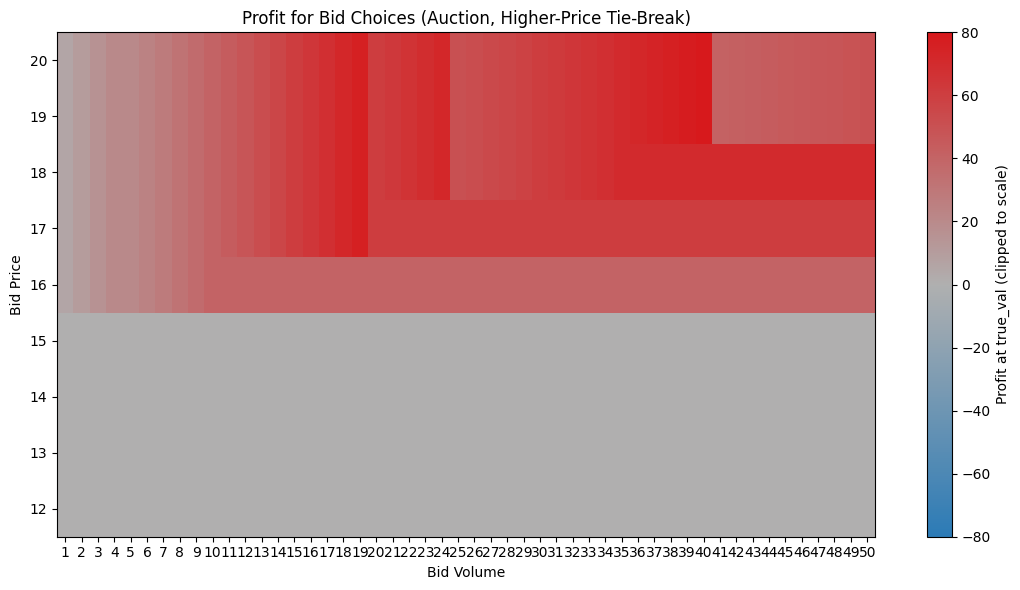

,bid_price,bid_volume,clearing_price,executed_volume,profit_at_true_val
0,12.0,1,15.0,0.0,0.0
1,12.0,2,15.0,0.0,0.0
2,12.0,3,15.0,0.0,0.0
3,12.0,4,15.0,0.0,0.0
4,12.0,5,15.0,0.0,0.0


In [13]:
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm


def simulate_last_in_queue_bid_sweep(
    csv_path: str,
    max_volume: int = 50,
    true_val: float | None = None,
    plot: bool = True,
    profit_vmin: float = -20.0,
    profit_vmax: float = 20.0,
):
    """Try placing our BID at each price and volume (1..max_volume).

    Auction rules used here:
    - Clearing price maximizes matched volume, tie-broken by higher price.
    - Execution has price priority.
    - At the same price level, existing queue executes first (our order is last).

    If true_val is provided, profit is computed as:
    profit = executed_volume * (true_val - clearing_price)
    """
    df = pd.read_csv(csv_path)
    required = {"BID", "PRICE", "ASK"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    if profit_vmin >= 0 or profit_vmax <= 0 or profit_vmin >= profit_vmax:
        raise ValueError("Use profit_vmin < 0 < profit_vmax for centered profit scaling.")

    base = (
        df[["BID", "PRICE", "ASK"]]
        .apply(pd.to_numeric, errors="coerce")
        .dropna(subset=["PRICE"])
        .fillna(0)
        .groupby("PRICE", as_index=False)[["BID", "ASK"]]
        .sum()
    )

    base_prices = np.sort(base["PRICE"].unique())
    bid_by_price = dict(zip(base["PRICE"], base["BID"]))
    ask_by_price = dict(zip(base["PRICE"], base["ASK"]))

    def _matched_curves(prices, bid_map, ask_map):
        b = np.array([bid_map.get(p, 0.0) for p in prices], dtype=float)
        a = np.array([ask_map.get(p, 0.0) for p in prices], dtype=float)
        demand_ge = b[::-1].cumsum()[::-1]   # buy volume willing to pay >= p
        supply_le = a.cumsum()               # sell volume willing to accept <= p
        matched = np.minimum(demand_ge, supply_le)
        return demand_ge, supply_le, matched

    def _choose_clearing_price(prices, matched):
        max_m = matched.max()
        idx = np.where(matched == max_m)[0]
        return prices[idx[-1]], max_m  # higher price tie-break

    records = []

    for test_price in base_prices:
        for vol in range(1, max_volume + 1):
            all_prices = np.unique(np.append(base_prices, test_price))
            all_prices.sort()

            bid_map = dict(bid_by_price)
            bid_map[test_price] = bid_map.get(test_price, 0.0) + vol
            ask_map = dict(ask_by_price)

            _, supply_le, matched = _matched_curves(all_prices, bid_map, ask_map)
            clearing_price, _ = _choose_clearing_price(all_prices, matched)

            cp_idx = np.where(all_prices == clearing_price)[0][0]
            total_supply = supply_le[cp_idx]
            buy_above_cp = sum(bid_map.get(p, 0.0) for p in all_prices if p > clearing_price)
            alloc_for_cp_bids = max(0.0, total_supply - buy_above_cp)

            if test_price > clearing_price:
                # Better price than clearing price: fully executed.
                our_exec = float(vol)
            elif test_price < clearing_price:
                our_exec = 0.0
            else:
                # At clearing price and last in queue: existing bids at cp fill first.
                existing_at_cp = bid_by_price.get(clearing_price, 0.0)
                remaining_after_existing = max(0.0, alloc_for_cp_bids - existing_at_cp)
                our_exec = float(min(vol, remaining_after_existing))

            profit_at_true_val = (
                float(our_exec * (true_val - clearing_price)) if true_val is not None else np.nan
            )

            records.append(
                {
                    "bid_price": float(test_price),
                    "bid_volume": int(vol),
                    "clearing_price": float(clearing_price),
                    "executed_volume": our_exec,
                    "profit_at_true_val": profit_at_true_val,
                }
            )

    result = pd.DataFrame(records)

    if plot:
        if true_val is None:
            raise ValueError("Set true_val to plot profit.")

        pivot = result.pivot(index="bid_price", columns="bid_volume", values="profit_at_true_val")

        # Center color mapping at zero with fixed profit caps.
        z = pivot.values.astype(float)
        z = np.clip(z, profit_vmin, profit_vmax)
        norm = TwoSlopeNorm(vmin=profit_vmin, vcenter=0.0, vmax=profit_vmax)
        cmap = LinearSegmentedColormap.from_list(
            "profit_blue_grey_red",
            ["#2C7BB6", "#B0B0B0", "#D7191C"],
            N=256,
        )

        fig, ax = plt.subplots(figsize=(11, 6))
        im = ax.imshow(z, aspect="auto", origin="lower", cmap=cmap, norm=norm)
        ax.set_title("Profit for Bid Choices (Auction, Higher-Price Tie-Break)")
        ax.set_xlabel("Bid Volume")
        ax.set_ylabel("Bid Price")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([f"{p:g}" for p in pivot.index])
        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label("Profit at true_val (clipped to scale)")
        plt.tight_layout()
        plt.show()

    return result


sweep = simulate_last_in_queue_bid_sweep(
    "EMBER_MUSHROOM.csv",
    max_volume=50,
    true_val=20,
    plot=True,
    profit_vmin=-80,
    profit_vmax=80,
)
sweep.head()

In [ ]:
# Sort by profit descending and print top rows
sweep_top = sweep.sort_values("profit_at_true_val", ascending=False)
print(sweep_top.head(20).to_string(index=False))

# Keep a display-friendly object as well
sweep_top.head(20)

 bid_price  bid_volume  clearing_price  executed_volume  profit_at_true_val
      19.0          40            18.0             40.0                80.0
      20.0          40            18.0             40.0                80.0
      19.0          39            18.0             39.0                78.0
      20.0          39            18.0             39.0                78.0
      19.0          38            18.0             38.0                76.0
      17.0          19            16.0             19.0                76.0
      18.0          19            16.0             19.0                76.0
      20.0          19            16.0             19.0                76.0
      20.0          38            18.0             38.0                76.0
      19.0          19            16.0             19.0                76.0
      20.0          37            18.0             37.0                74.0
      19.0          37            18.0             37.0                74.0
      19.0  

,bid_price,bid_volume,clearing_price,executed_volume,profit_at_true_val
389,19.0,40,18.0,40.0,80.0
439,20.0,40,18.0,40.0,80.0
388,19.0,39,18.0,39.0,78.0
438,20.0,39,18.0,39.0,78.0
387,19.0,38,18.0,38.0,76.0
268,17.0,19,16.0,19.0,76.0
318,18.0,19,16.0,19.0,76.0
418,20.0,19,16.0,19.0,76.0
437,20.0,38,18.0,38.0,76.0
368,19.0,19,16.0,19.0,76.0


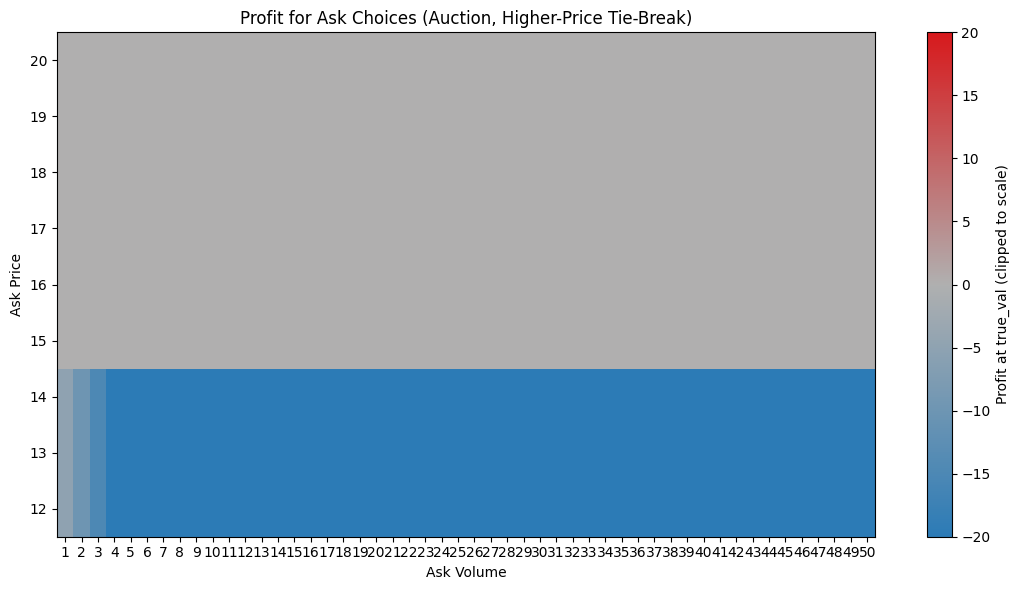

,ask_price,ask_volume,clearing_price,executed_volume,profit_at_true_val
0,12.0,1,15.0,1.0,-5.0
1,12.0,2,15.0,2.0,-10.0
2,12.0,3,15.0,3.0,-15.0
3,12.0,4,15.0,4.0,-20.0
4,12.0,5,15.0,5.0,-25.0


In [12]:
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm


def simulate_last_in_queue_ask_sweep(
    csv_path: str,
    max_volume: int = 50,
    true_val: float | None = None,
    plot: bool = True,
    profit_vmin: float = -20.0,
    profit_vmax: float = 20.0,
):
    """Try placing our ASK at each price and volume (1..max_volume).

    Auction rules used here:
    - Clearing price maximizes matched volume, tie-broken by higher price.
    - Execution has price priority.
    - At the same price level, existing queue executes first (our order is last).

    If true_val is provided, ask-side profit is computed as:
    profit = executed_volume * (clearing_price - true_val)
    """
    df = pd.read_csv(csv_path)
    required = {"BID", "PRICE", "ASK"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    if profit_vmin >= 0 or profit_vmax <= 0 or profit_vmin >= profit_vmax:
        raise ValueError("Use profit_vmin < 0 < profit_vmax for centered profit scaling.")

    base = (
        df[["BID", "PRICE", "ASK"]]
        .apply(pd.to_numeric, errors="coerce")
        .dropna(subset=["PRICE"])
        .fillna(0)
        .groupby("PRICE", as_index=False)[["BID", "ASK"]]
        .sum()
    )

    base_prices = np.sort(base["PRICE"].unique())
    bid_by_price = dict(zip(base["PRICE"], base["BID"]))
    ask_by_price = dict(zip(base["PRICE"], base["ASK"]))

    def _matched_curves(prices, bid_map, ask_map):
        b = np.array([bid_map.get(p, 0.0) for p in prices], dtype=float)
        a = np.array([ask_map.get(p, 0.0) for p in prices], dtype=float)
        demand_ge = b[::-1].cumsum()[::-1]   # buy volume willing to pay >= p
        supply_le = a.cumsum()               # sell volume willing to accept <= p
        matched = np.minimum(demand_ge, supply_le)
        return demand_ge, supply_le, matched

    def _choose_clearing_price(prices, matched):
        max_m = matched.max()
        idx = np.where(matched == max_m)[0]
        return prices[idx[-1]], max_m  # higher price tie-break

    records = []

    for test_price in base_prices:
        for vol in range(1, max_volume + 1):
            all_prices = np.unique(np.append(base_prices, test_price))
            all_prices.sort()

            bid_map = dict(bid_by_price)
            ask_map = dict(ask_by_price)
            ask_map[test_price] = ask_map.get(test_price, 0.0) + vol

            demand_ge, _, matched = _matched_curves(all_prices, bid_map, ask_map)
            clearing_price, _ = _choose_clearing_price(all_prices, matched)

            cp_idx = np.where(all_prices == clearing_price)[0][0]
            total_demand = demand_ge[cp_idx]
            sell_below_cp = sum(ask_map.get(p, 0.0) for p in all_prices if p < clearing_price)
            alloc_for_cp_asks = max(0.0, total_demand - sell_below_cp)

            if test_price < clearing_price:
                # Better price than clearing price: fully executed.
                our_exec = float(vol)
            elif test_price > clearing_price:
                our_exec = 0.0
            else:
                # At clearing price and last in queue: existing asks at cp fill first.
                existing_at_cp = ask_by_price.get(clearing_price, 0.0)
                remaining_after_existing = max(0.0, alloc_for_cp_asks - existing_at_cp)
                our_exec = float(min(vol, remaining_after_existing))

            profit_at_true_val = (
                float(our_exec * (clearing_price - true_val)) if true_val is not None else np.nan
            )

            records.append(
                {
                    "ask_price": float(test_price),
                    "ask_volume": int(vol),
                    "clearing_price": float(clearing_price),
                    "executed_volume": our_exec,
                    "profit_at_true_val": profit_at_true_val,
                }
            )

    result = pd.DataFrame(records)

    if plot:
        if true_val is None:
            raise ValueError("Set true_val to plot profit.")

        pivot = result.pivot(index="ask_price", columns="ask_volume", values="profit_at_true_val")

        z = pivot.values.astype(float)
        z = np.clip(z, profit_vmin, profit_vmax)
        norm = TwoSlopeNorm(vmin=profit_vmin, vcenter=0.0, vmax=profit_vmax)
        cmap = LinearSegmentedColormap.from_list(
            "profit_blue_grey_red",
            ["#2C7BB6", "#B0B0B0", "#D7191C"],
            N=256,
        )

        fig, ax = plt.subplots(figsize=(11, 6))
        im = ax.imshow(z, aspect="auto", origin="lower", cmap=cmap, norm=norm)
        ax.set_title("Profit for Ask Choices (Auction, Higher-Price Tie-Break)")
        ax.set_xlabel("Ask Volume")
        ax.set_ylabel("Ask Price")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([f"{p:g}" for p in pivot.index])
        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label("Profit at true_val (clipped to scale)")
        plt.tight_layout()
        plt.show()

    return result


ask_sweep = simulate_last_in_queue_ask_sweep(
    "EMBER_MUSHROOM.csv",
    max_volume=50,
    true_val=20,
    plot=True,
    profit_vmin=-20,
    profit_vmax=20,
)
ask_sweep.head()

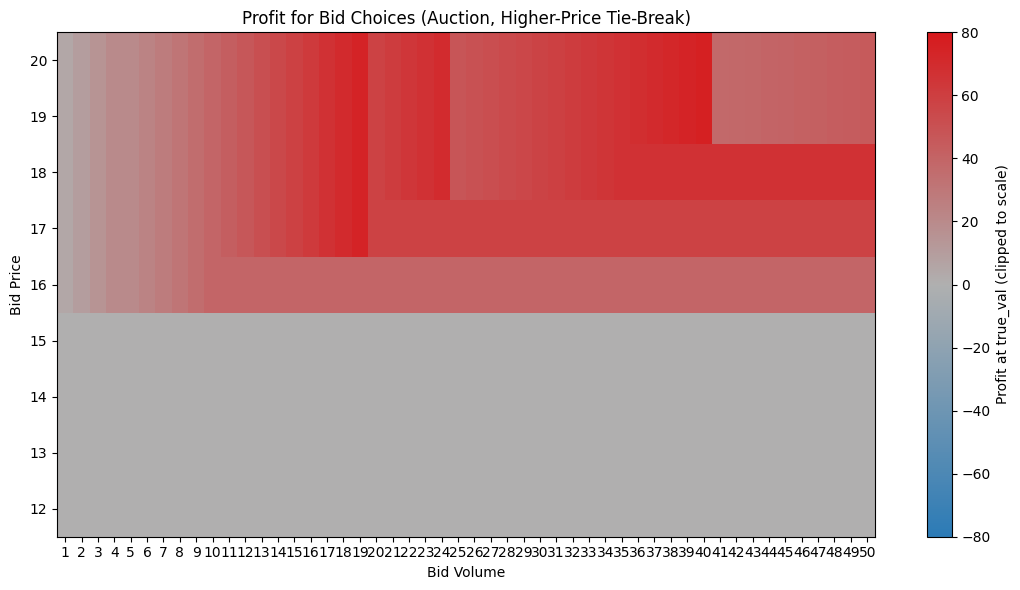

,bid_price,bid_volume,clearing_price,executed_volume,profit_at_true_val
0,12.0,1,15.0,0.0,0.0
1,12.0,2,15.0,0.0,0.0
2,12.0,3,15.0,0.0,0.0
3,12.0,4,15.0,0.0,0.0
4,12.0,5,15.0,0.0,0.0


In [17]:
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm


def simulate_last_in_queue_bid_sweep(
    csv_path: str,
    max_volume: int = 50,
    true_val: float | None = None,
    plot: bool = True,
    profit_vmin: float = -20.0,
    profit_vmax: float = 20.0,
    fee_per_volume: float = 0.05,
):
    """Try placing our BID at each price and volume (1..max_volume).

    Auction rules used here:
    - Clearing price maximizes matched volume, tie-broken by higher price.
    - Execution has price priority.
    - At the same price level, existing queue executes first (our order is last).

    If true_val is provided, profit is computed as:
    profit = executed_volume * (true_val - clearing_price) - executed_volume * fee_per_volume
    """
    df = pd.read_csv(csv_path)
    required = {"BID", "PRICE", "ASK"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    if profit_vmin >= 0 or profit_vmax <= 0 or profit_vmin >= profit_vmax:
        raise ValueError("Use profit_vmin < 0 < profit_vmax for centered profit scaling.")

    if fee_per_volume < 0:
        raise ValueError("fee_per_volume must be non-negative.")

    base = (
        df[["BID", "PRICE", "ASK"]]
        .apply(pd.to_numeric, errors="coerce")
        .dropna(subset=["PRICE"])
        .fillna(0)
        .groupby("PRICE", as_index=False)[["BID", "ASK"]]
        .sum()
    )

    base_prices = np.sort(base["PRICE"].unique())
    bid_by_price = dict(zip(base["PRICE"], base["BID"]))
    ask_by_price = dict(zip(base["PRICE"], base["ASK"]))

    def _matched_curves(prices, bid_map, ask_map):
        b = np.array([bid_map.get(p, 0.0) for p in prices], dtype=float)
        a = np.array([ask_map.get(p, 0.0) for p in prices], dtype=float)
        demand_ge = b[::-1].cumsum()[::-1]   # buy volume willing to pay >= p
        supply_le = a.cumsum()               # sell volume willing to accept <= p
        matched = np.minimum(demand_ge, supply_le)
        return demand_ge, supply_le, matched

    def _choose_clearing_price(prices, matched):
        max_m = matched.max()
        idx = np.where(matched == max_m)[0]
        return prices[idx[-1]], max_m  # higher price tie-break

    records = []

    for test_price in base_prices:
        for vol in range(1, max_volume + 1):
            all_prices = np.unique(np.append(base_prices, test_price))
            all_prices.sort()

            bid_map = dict(bid_by_price)
            bid_map[test_price] = bid_map.get(test_price, 0.0) + vol
            ask_map = dict(ask_by_price)

            _, supply_le, matched = _matched_curves(all_prices, bid_map, ask_map)
            clearing_price, _ = _choose_clearing_price(all_prices, matched)

            cp_idx = np.where(all_prices == clearing_price)[0][0]
            total_supply = supply_le[cp_idx]
            buy_above_cp = sum(bid_map.get(p, 0.0) for p in all_prices if p > clearing_price)
            alloc_for_cp_bids = max(0.0, total_supply - buy_above_cp)

            if test_price > clearing_price:
                # Better price than clearing price: fully executed.
                our_exec = float(vol)
            elif test_price < clearing_price:
                our_exec = 0.0
            else:
                # At clearing price and last in queue: existing bids at cp fill first.
                existing_at_cp = bid_by_price.get(clearing_price, 0.0)
                remaining_after_existing = max(0.0, alloc_for_cp_bids - existing_at_cp)
                our_exec = float(min(vol, remaining_after_existing))

            profit_at_true_val = (
                float(our_exec * (true_val - clearing_price - fee_per_volume))
                if true_val is not None
                else np.nan
            )

            records.append(
                {
                    "bid_price": float(test_price),
                    "bid_volume": int(vol),
                    "clearing_price": float(clearing_price),
                    "executed_volume": our_exec,
                    "profit_at_true_val": profit_at_true_val,
                }
            )

    result = pd.DataFrame(records)

    if plot:
        if true_val is None:
            raise ValueError("Set true_val to plot profit.")

        pivot = result.pivot(index="bid_price", columns="bid_volume", values="profit_at_true_val")

        # Center color mapping at zero with fixed profit caps.
        z = pivot.values.astype(float)
        z = np.clip(z, profit_vmin, profit_vmax)
        norm = TwoSlopeNorm(vmin=profit_vmin, vcenter=0.0, vmax=profit_vmax)
        cmap = LinearSegmentedColormap.from_list(
            "profit_blue_grey_red",
            ["#2C7BB6", "#B0B0B0", "#D7191C"],
            N=256,
        )

        fig, ax = plt.subplots(figsize=(11, 6))
        im = ax.imshow(z, aspect="auto", origin="lower", cmap=cmap, norm=norm)
        ax.set_title("Profit for Bid Choices (Auction, Higher-Price Tie-Break)")
        ax.set_xlabel("Bid Volume")
        ax.set_ylabel("Bid Price")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([f"{p:g}" for p in pivot.index])
        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label("Profit at true_val (clipped to scale)")
        plt.tight_layout()
        plt.show()

    return result


sweep = simulate_last_in_queue_bid_sweep(
    "EMBER_MUSHROOM.csv",
    max_volume=50,
    true_val=20,
    plot=True,
    profit_vmin=-80,
    profit_vmax=80,
    fee_per_volume=0.1,
)
sweep.head()

In [18]:
# Sort by profit descending and print top rows
sweep_top = sweep.sort_values("profit_at_true_val", ascending=False)
print(sweep_top.head(20).to_string(index=False))

# Keep a display-friendly object as well
sweep_top.head(20)

 bid_price  bid_volume  clearing_price  executed_volume  profit_at_true_val
      19.0          40            18.0             40.0                76.0
      20.0          40            18.0             40.0                76.0
      19.0          39            18.0             39.0                74.1
      17.0          19            16.0             19.0                74.1
      20.0          39            18.0             39.0                74.1
      18.0          19            16.0             19.0                74.1
      19.0          19            16.0             19.0                74.1
      20.0          19            16.0             19.0                74.1
      19.0          38            18.0             38.0                72.2
      20.0          38            18.0             38.0                72.2
      20.0          37            18.0             37.0                70.3
      19.0          37            18.0             37.0                70.3
      17.0  

,bid_price,bid_volume,clearing_price,executed_volume,profit_at_true_val
389,19.0,40,18.0,40.0,76.0
439,20.0,40,18.0,40.0,76.0
388,19.0,39,18.0,39.0,74.1
268,17.0,19,16.0,19.0,74.1
438,20.0,39,18.0,39.0,74.1
318,18.0,19,16.0,19.0,74.1
368,19.0,19,16.0,19.0,74.1
418,20.0,19,16.0,19.0,74.1
387,19.0,38,18.0,38.0,72.2
437,20.0,38,18.0,38.0,72.2


In [4]:
import pandas as pd
import numpy as np


def sweep_bid_quantity_range_auction(
    csv_path: str,
    quantity_range_min: float,
    quantity_range_max: float,
    bid_price: float,
    true_val: float = 20.0,
    fee_per_volume: float = 0.0,
    step: float = 0.001,
):
    """Sweep candidate bid quantities and evaluate auction outcome for each.

    Uses auction clearing-price logic:
    - Clearing price maximizes matched volume, tie-broken by higher price.

    Execution rule for our tested order:
    - Price priority applies.
    - No time priority at the same price (pro-rata allocation at clearing price).

    Profit:
    - executed_volume * (true_val - clearing_price - fee_per_volume)
    """
    if step <= 0:
        raise ValueError("step must be > 0")
    if quantity_range_max < quantity_range_min:
        raise ValueError("quantity_range_max must be >= quantity_range_min")
    if bid_price <= 0:
        raise ValueError("bid_price must be > 0")

    df = pd.read_csv(csv_path)
    required = {"BID", "PRICE", "ASK"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    base = (
        df[["BID", "PRICE", "ASK"]]
        .apply(pd.to_numeric, errors="coerce")
        .dropna(subset=["PRICE"])
        .fillna(0)
        .groupby("PRICE", as_index=False)[["BID", "ASK"]]
        .sum()
    )

    base_prices = np.sort(base["PRICE"].unique())
    bid_by_price = dict(zip(base["PRICE"], base["BID"]))
    ask_by_price = dict(zip(base["PRICE"], base["ASK"]))

    def _matched_curves(prices, bid_map, ask_map):
        bids = np.array([bid_map.get(p, 0.0) for p in prices], dtype=float)
        asks = np.array([ask_map.get(p, 0.0) for p in prices], dtype=float)
        demand_ge = bids[::-1].cumsum()[::-1]
        supply_le = asks.cumsum()
        matched = np.minimum(demand_ge, supply_le)
        return demand_ge, supply_le, matched

    def _choose_clearing_price(prices, matched):
        max_m = matched.max()
        idx = np.where(matched == max_m)[0]
        return prices[idx[-1]], max_m

    n_steps = int(round((quantity_range_max - quantity_range_min) / step))
    records = []

    for i in range(n_steps + 1):
        test_qty = round(quantity_range_min + i * step, 3)

        all_prices = np.unique(np.append(base_prices, bid_price))
        all_prices.sort()

        bid_map = dict(bid_by_price)
        ask_map = dict(ask_by_price)
        bid_map[bid_price] = bid_map.get(bid_price, 0.0) + test_qty

        _, supply_le, matched = _matched_curves(all_prices, bid_map, ask_map)
        clearing_price, matched_volume = _choose_clearing_price(all_prices, matched)

        cp_idx = np.where(all_prices == clearing_price)[0][0]
        total_supply = supply_le[cp_idx]
        buy_above_cp = sum(bid_map.get(p, 0.0) for p in all_prices if p > clearing_price)
        alloc_for_cp_bids = max(0.0, total_supply - buy_above_cp)

        if bid_price > clearing_price:
            executed = float(test_qty)
        elif bid_price < clearing_price:
            executed = 0.0
        else:
            # Same price as clearing: pro-rata among all bids at clearing price.
            existing_at_cp = bid_by_price.get(clearing_price, 0.0)
            total_at_cp = existing_at_cp + test_qty
            if total_at_cp <= 0:
                executed = 0.0
            else:
                executed = float(min(test_qty, alloc_for_cp_bids * (test_qty / total_at_cp)))

        score = float(executed * (true_val - clearing_price - fee_per_volume))

        records.append(
            {
                "bid_price": float(bid_price),
                "bid_quantity": float(test_qty),
                "clearing_price": float(clearing_price),
                "matched_volume": float(matched_volume),
                "executed_volume": executed,
                "score": score,
            }
        )

    return pd.DataFrame(records)


# Example: sweep quantity from 39 to 41 in 0.001 increments for fixed bid price=19
results = sweep_bid_quantity_range_auction(
    "EMBER_MUSHROOM.csv",
    quantity_range_min=39,
    quantity_range_max=42,
    bid_price=19,
    true_val=20,
    fee_per_volume=0.1,
    step=0.001,
)

best_result = results.loc[results["score"].idxmax()]
print(
    f"Best qty={best_result['bid_quantity']:.3f}, "
    f"bid={best_result['bid_price']:.3f}, "
    f"clearing={best_result['clearing_price']:.3f}, "
    f"exec={best_result['executed_volume']:.3f}, "
    f"score={best_result['score']:.3f}"
)
print(f"Total iterations: {len(results)}")
results.head()

Best qty=40.999, bid=19.000, clearing=18.000, exec=40.999, score=77.898
Total iterations: 3001


,bid_price,bid_quantity,clearing_price,matched_volume,executed_volume,score
0,19.0,39.000,18.0,101.0,39.000,74.1000
1,19.0,39.001,18.0,101.0,39.001,74.1019
2,19.0,39.002,18.0,101.0,39.002,74.1038
3,19.0,39.003,18.0,101.0,39.003,74.1057
4,19.0,39.004,18.0,101.0,39.004,74.1076
